> 📘 This notebook is created and maintained by **Teslim Uthman Adeyanju**  
> 📧 Connect with me on [LinkedIn](https://www.linkedin.com/in/adeyanjuteslimuthman) or visit my [website](https://adeyanjuteslim.co.uk).  
> 🔗 [LinkedIn](https://www.linkedin.com/in/adeyanjuteslimuthman) | 🌐 [Blog](https://adeyanjuteslim.co.uk) | 📬 [info@adeyanjuteslim.co.uk](mailto:info@adeyanjuteslim.co.uk)


# **Customer Behavior & Marketing Influence Prediction Project**
___

Goal: Understand customer behavior patterns and predict their return likelihood and marketing influence. Also, identify customer segments using clustering techniques. Deploy an interactive dashboard for stakeholders.

### Table of Contents

The notebook is organized into the following sections:
1. **Introduction**
2. **Data Preprocessing**
3. **Exploratory Data Analysis (EDA)**
4. **Feature Engineering**
5. **Modeling**
6. **Clustering**
7. **Model Evaluation**
8. **Deployment**

# 📚 1.0 INTRODUCTION


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section provides an overview of the dataset and the problem we are trying to solve. We will also discuss the data overview, project objective, methodology and the tools (libaries) we will use to solve the problem.

</div>

## 🔍 1.1 Project Overview
____

**Link to Dataset**: [TechCorner Mobile Purchase & Engagement Data](https://www.kaggle.com/datasets/shohinurpervezshohan/techcorner-mobile-purchase-and-engagement-data)

The project focuses on analyzing customer behavioral patterns and evaluating the impact of marketing strategies (such as Facebook engagement and word-of-mouth referrals) on purchasing behavior. By using classification and clustering models, this project aims to:

- Predict whether a customer will return,
- Determine if a customer was influenced by Facebook marketing,
- Segment customers into meaningful groups based on their engagement and purchase attributes.

This tool can be helpful for business decision-makers, marketing teams, and retail analysts who want to understand how different channels influence customer retention and purchases.


**Dataset Summary**

This project uses a real-world dataset containing customer engagement and sales data collected from a mobile phone retail shop. The dataset has rows representing individual customers and includes categorical and numerical attributes relevant to understanding purchase decisions and customer profiles.

**Dataset Features**

| Feature                                   | Description                                                        |
|-------------------------------------------|--------------------------------------------------------------------|
| `Cus.ID`                                  | Unique identifier for each customer                                |
| `Date`                                    | Date of the customer’s visit or purchase                           |
| `Cus. Location`                           | Customer's location (e.g., Rangamati Sadar, Outside Rangamati)     |
| `Age`                                     | Age of the customer                                                |
| `Gender`                                  | Gender of the customer (Male/Female)                               |
| `Mobile Name`                             | Brand and model of the mobile purchased                            |
| `Sell Price`                              | Price at which the mobile was sold (numeric)                       |
| `Does he/she Come from Facebook Page?`    | Whether the customer arrived through Facebook                      |
| `Does he/she Followed Our Page?`          | Whether the customer follows the store's Facebook page             |
| `Did he/she buy any mobile before?`       | Whether the customer has previously made a purchase                |
| `Did he/she hear of our shop before?`     | Whether the customer had prior awareness of the shop               |



<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

## 🔍 1.2 Project Objective
___

The main objective of this project is to analyze customer behavior and marketing influence on purchasing decisions. The specific goals include:


### Exploratory Data Analysis (EDA)
- Identify trends in customer source (e.g., Facebook, referral, walk-in)
- Analyze demographic patterns (age, gender, location)
- Examine brand preferences and mobile price distributions

### Classification Models
- Predict whether a customer will **return** in the future
- Predict whether a customer was **influenced by Facebook marketing**

### Clustering Models
- Segment customers into behavioral groups based on:
  - Demographics
  - Purchase behavior
  - Marketing engagement (e.g., follows page, referral)

### Deployment
- Build a user-friendly **Streamlit web app** to:
  - Accept customer input for real-time predictions
  - Visualize clusters and customer types
  - Explore dashboards with marketing insights


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

## 🔍 1.3 Library Tools
___

The success of this project hinges on leveraging powerful Python libraries that enable prediction, feature engineering, modeling, and insightful visualization. These tools form the backbone of our notebook, streamlining the end-to-end process—from data retrieval and preparation to modeling and evaluation.

Below is a breakdown of the core libraries used in this project, logically grouped by functionality, along with their specific roles:

#### Data Manipulation and Analysis
- **`pandas`**: Data manipulation and preprocessing (e.g., filtering, grouping, merging)
- **`numpy`**: Numerical computations and array handling
- **`scipy`**: Statistical analysis and scientific computing


#### Data Visualization
- **`matplotlib`**: Foundational plotting library for static, animated, and interactive visualizations
- **`seaborn`**: High-level interface for drawing attractive statistical graphics built on top of matplotlib

#### Machine Learning
- **`scikit-learn`**: Comprehensive toolkit for modeling, preprocessing, pipelines, and feature selection
- **`xgboost`**: Efficient and scalable gradient boosting for classification and regression
- **`lightgbm`**: Fast, distributed, high-performance gradient boosting framework based on decision tree algorithms
- **`catboost`**: Gradient boosting library with support for categorical variables
- **`yellowbrick`**: Visual diagnostic tools for machine learning workflows


#### Model Evaluation and Selection
- **`sklearn.metrics`**: Metrics such as Accuracy, Precision, Recall, F1-Score, ROC-AUC for model evaluation
- **`sklearn.model_selection`**: Train-test splitting, cross-validation, and hyperparameter tuning utilities


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

# 📚 2.0 DATA PREPROCESSING


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

This section focuses on loading the dataset and performing data preprocessing tasks such as handling missing values, changing data types, and confirming the absence of duplicates. This will make our dataset ready for exploratory data analysis and model development.
</div>

## 🔍 2.1.0 Import Libraries
___

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings


# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable, coolwarm
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('ggplot')


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

## 🔍 2.2.0 Data Loading 
___

In [17]:
# Importing the dataset
df = pd.read_csv("data.csv", parse_dates=['Date'], dayfirst=True)

df.head()

,Cus.ID,Date,Cus. Location,Age,Gender,Mobile Name,Sell Price,Does he/she Come from Facebook Page?,Does he/she Followed Our Page?,Did he/she buy any mobile before?,Did he/she hear of our shop before?
0,1,2024-05-27,Rangamati Sadar,49,F,Galaxy A55 5G 8/128,17073.0,No,Yes,No,Yes
1,2,2024-05-27,Inside Rangamati,44,M,Redmi Note 12 Pro 8/128,15546.0,Yes,No,No,Yes
2,3,2024-05-27,Rangamati Sadar,45,M,R-70 Turbo 5G 6/128,26516.0,Yes,No,No,Yes
3,4,2024-05-27,Rangamati Sadar,46,M,R-70 Turbo 5G 6/128,21927.0,No,No,No,Yes
4,5,2024-05-27,Outside Rangamati,27,F,Vivo T3x 5G 8/128,16718.0,Yes,No,No,Yes


The dataset contains the following columns:

In [18]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8871 entries, 0 to 8870
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Cus.ID                                8871 non-null   int64         
 1   Date                                  8871 non-null   datetime64[ns]
 2   Cus. Location                         8871 non-null   object        
 3   Age                                   8871 non-null   int64         
 4   Gender                                8871 non-null   object        
 5   Mobile Name                           8871 non-null   object        
 6   Sell Price                            8871 non-null   float64       
 7   Does he/she Come from Facebook Page?  8871 non-null   object        
 8   Does he/she Followed Our Page?        8871 non-null   object        
 9   Did he/she buy any mobile before?     8871 non-null   object        
 10  

## 🔍 2.3.0 Data Cleaning and Formatting
___

It is important to check the data frame shape before starting the data processing. This is important to know the number of rows and columns in the dataset.

In [19]:
# check the dataframe shape
df.shape

(8871, 11)

In [20]:
df.columns.to_list()

['Cus.ID',
 'Date',
 'Cus. Location',
 'Age',
 'Gender',
 'Mobile Name',
 'Sell Price',
 'Does he/she Come from Facebook Page?',
 'Does he/she Followed Our Page?',
 'Did he/she buy any mobile before?',
 'Did he/she hear of our shop before?']

In [22]:
# Rename columns for clarity and simplicity
df.columns = [
    'customer_id',
    'visit_date',
    'customer_location',
    'age',
    'gender',
    'mobile_name',
    'sell_price',
    'came_from_facebook',
    'follows_facebook_page',
    'previous_customer',
    'heard_about_shop',
]

In [23]:
# separate the numerical and categorical columns
numerical = df.select_dtypes(include=['number']).columns
categorical = df.select_dtypes(include=['object']).columns

In [24]:
# transforming those columns to uniform content 
def clean_column_content(df, column_name):
    df[column_name] = df[column_name].astype(str)
    df[column_name] = df[column_name].str.lower()
    df[column_name] = df[column_name].str.replace(' ', '_')
    return df

for col in categorical:
    clean_categorical_data_for_use = clean_column_content(df, col)
    
df
    

,customer_id,visit_date,customer_location,age,gender,mobile_name,sell_price,came_from_facebook,follows_facebook_page,previous_customer,heard_about_shop
0,1,2024-05-27,rangamati_sadar,49,f,galaxy_a55_5g_8/128,17073.0,no,yes,no,yes
1,2,2024-05-27,inside_rangamati,44,m,redmi_note_12_pro_8/128,15546.0,yes,no,no,yes
2,3,2024-05-27,rangamati_sadar,45,m,r-70_turbo_5g_6/128,26516.0,yes,no,no,yes
3,4,2024-05-27,rangamati_sadar,46,m,r-70_turbo_5g_6/128,21927.0,no,no,no,yes
4,5,2024-05-27,outside_rangamati,27,f,vivo_t3x_5g_8/128,16718.0,yes,no,no,yes
...,...,...,...,...,...,...,...,...,...,...,...
8866,8867,2025-03-22,outside_rangamati,34,m,iqoo_neo_9_pro_5g_12/256,21682.0,yes,yes,yes,yes
8867,8868,2025-03-22,inside_rangamati,48,m,moto_g85_5g_8/128,26493.0,no,no,no,no
8868,8869,2025-03-22,inside_rangamati,30,f,galaxy_m35_5g_8/128,16184.0,no,no,no,no
8869,8870,2025-03-22,inside_rangamati,22,f,galaxy_a55_5g_8/128,16663.0,yes,no,no,yes


In [9]:
# check for the missing values
df.isnull().sum() / df.shape[0] * 100

customer_id              0.0
visit_date               0.0
customer_location        0.0
age                      0.0
gender                   0.0
mobile_name              0.0
sell_price               0.0
came_from_facebook       0.0
follows_facebook_page    0.0
previous_customer        0.0
heard_about_shop         0.0
dtype: float64

In [25]:
# check the numerical columns
numerical.to_list()

['customer_id', 'age', 'sell_price']

In [26]:
# check the categorical columns
categorical.to_list()

['customer_location',
 'gender',
 'mobile_name',
 'came_from_facebook',
 'follows_facebook_page',
 'previous_customer',
 'heard_about_shop']

It is important to check Check Cardinality (Number of Unique Categories) of Categorical Columns. This will help us to identify the number of unique categories in each categorical column. This information will be useful for encoding categorical variables later in the project.

In [12]:
# Loop through categorical columns
for col in categorical:
  
  # Print the number of unique values
  print(f"Number of unique values in {col} column: ", df[col].nunique())

Number of unique values in customer_location column:  3
Number of unique values in gender column:  2
Number of unique values in mobile_name column:  17
Number of unique values in came_from_facebook column:  2
Number of unique values in follows_facebook_page column:  2
Number of unique values in previous_customer column:  2
Number of unique values in heard_about_shop column:  2


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8871 entries, 0 to 8870
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            8871 non-null   int64         
 1   visit_date             8871 non-null   datetime64[ns]
 2   customer_location      8871 non-null   object        
 3   age                    8871 non-null   int64         
 4   gender                 8871 non-null   object        
 5   mobile_name            8871 non-null   object        
 6   sell_price             8871 non-null   float64       
 7   came_from_facebook     8871 non-null   object        
 8   follows_facebook_page  8871 non-null   object        
 9   previous_customer      8871 non-null   object        
 10  heard_about_shop       8871 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 762.5+ KB


# 📚 3.0 EXPLORATORY DATA ANALYSIS

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section will focus on data visualization and statistical analysis to understand the distribution of attributes of categorical and numerical and relationships between them. We will use plots such as histograms, scatter plots, and correlation matrices to identify patterns and trends in the data.

</div>

## 🔍 3.1.0 Understanding Categorical Features
___

### customer_location

In [ ]:
print(df['customer_location'].value_counts(normalize=True))

customer_location
outside_rangamati    0.338181
rangamati_sadar      0.335024
inside_rangamati     0.326795
Name: proportion, dtype: float64


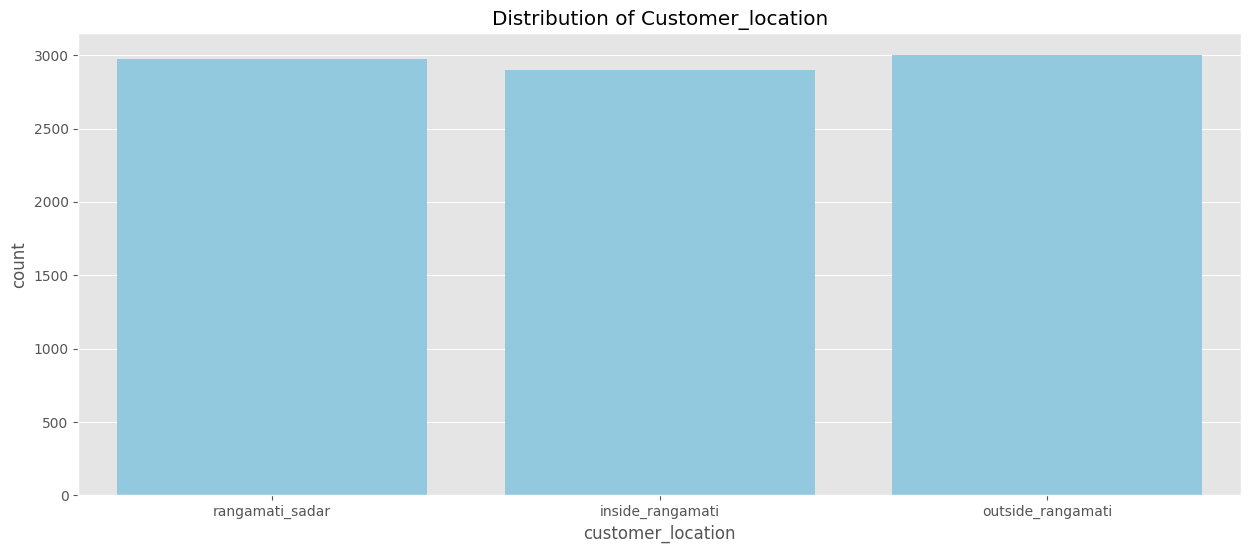

In [78]:
# visualize the distribution of the cut column
fig, ax = plt.subplots(figsize=(15, 6))
sns.countplot(x='customer_location', data=df, color='skyblue')
plt.title('Distribution of Customer_location')
plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This near-even split suggests that customer engagement is not heavily skewed toward any single location. The dataset is well-distributed geographically, which supports fair comparative analysis across regions. It also indicates that any marketing or customer behavior insights drawn from this data can be generalized across the different locations with reasonable confidence.

### Gender Distribution

In [43]:
print((df['gender'].value_counts(normalize=True) * 100).round())

gender
f    50.0
m    50.0
Name: proportion, dtype: float64


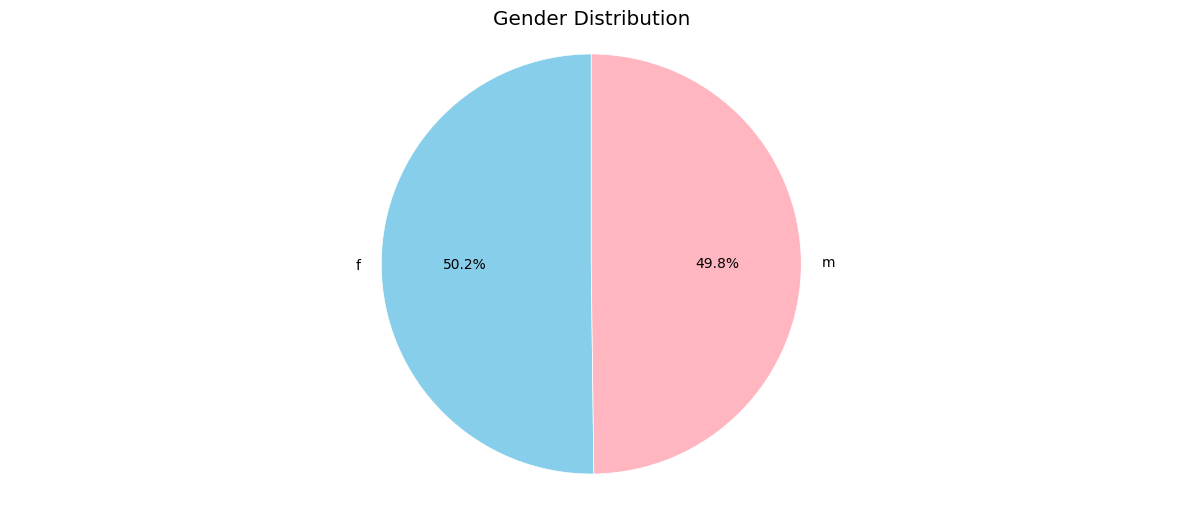

In [53]:
# Gender distribution as a pie chart
gender_counts = df['gender'].value_counts()
labels = gender_counts.index
sizes = gender_counts.values

fig, ax = plt.subplots(figsize=(15, 6))
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['skyblue', 'lightpink'], 
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Gender Distribution")
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
🖐️ <strong>Insight on Gender:</strong><br>
The gender  distribution is a balance dataset with male and female participants, indicating a diverse representation in the dataset. This balance is crucial for ensuring that any analysis or model built on this data is fair and unbiased. 

</div>

### mobile_name 

In [48]:
print(df['mobile_name'].value_counts())

mobile_name
moto_g85_5g_8/128           560
galaxy_s24_ultra_12/256     541
note_11s_6/128              538
pixel_8_pro_12/256          533
narzo_n53_4/64              530
redmi_note_12_pro_8/128     528
galaxy_m35_5g_8/128         528
galaxy_a55_5g_8/128         522
iqoo_z7_5g_6/128            522
iphone_16_pro_256gb         521
vivo_y200_5g_6/128          520
pixel_7a_8/128              518
vivo_t3x_5g_8/128           514
r-70_turbo_5g_6/128         511
iqoo_neo_9_pro_5g_12/256    502
note_14_pro_5g_8/256        495
iphone_16_pro_max_1tb       488
Name: count, dtype: int64


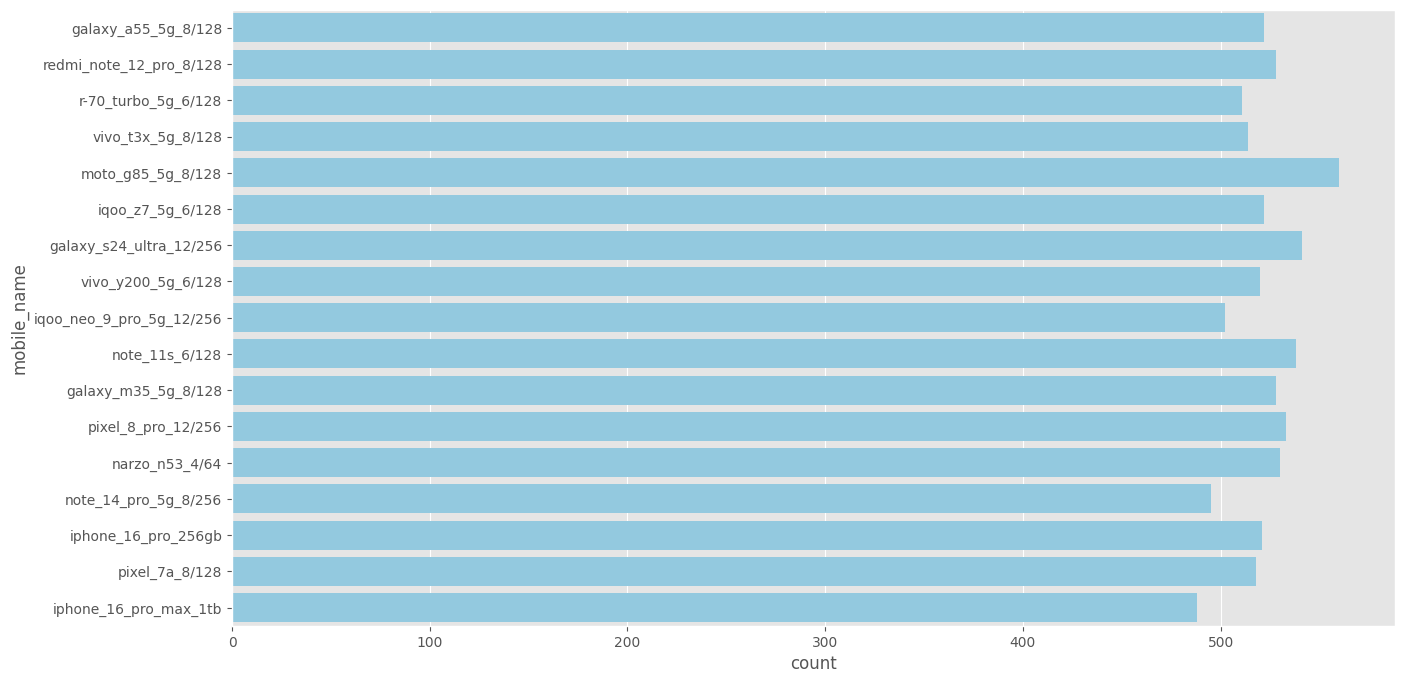

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=df, y='mobile_name', color='skyblue')
plt.show()

### came_from_facebook 

In [72]:
print(df['came_from_facebook'].value_counts())

came_from_facebook
no     5781
yes    3090
Name: count, dtype: int64


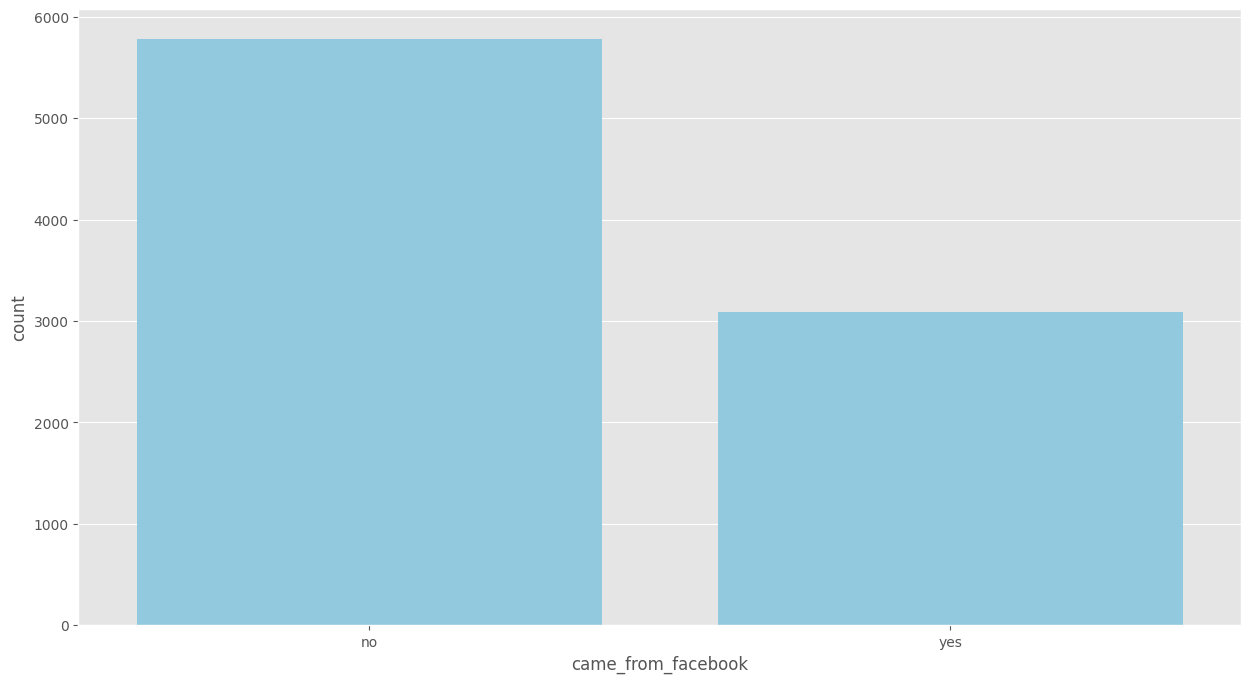

In [74]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=df, x='came_from_facebook', color='skyblue')
plt.show()

### follows_facebook_page

In [55]:
print(df['follows_facebook_page'].value_counts())

follows_facebook_page
no     5314
yes    3557
Name: count, dtype: int64


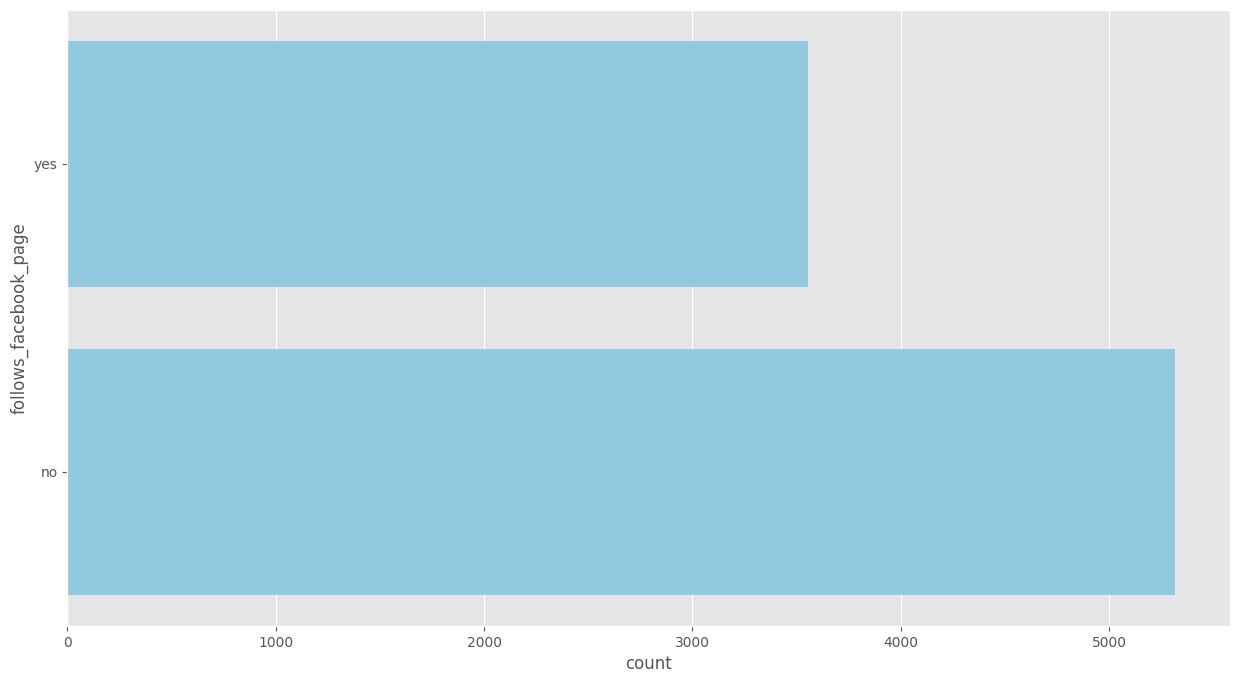

In [83]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=df, y='follows_facebook_page', color='skyblue')
plt.show()

### previous_customer 

In [56]:
print(df['previous_customer'].value_counts())

previous_customer
no     6677
yes    2194
Name: count, dtype: int64


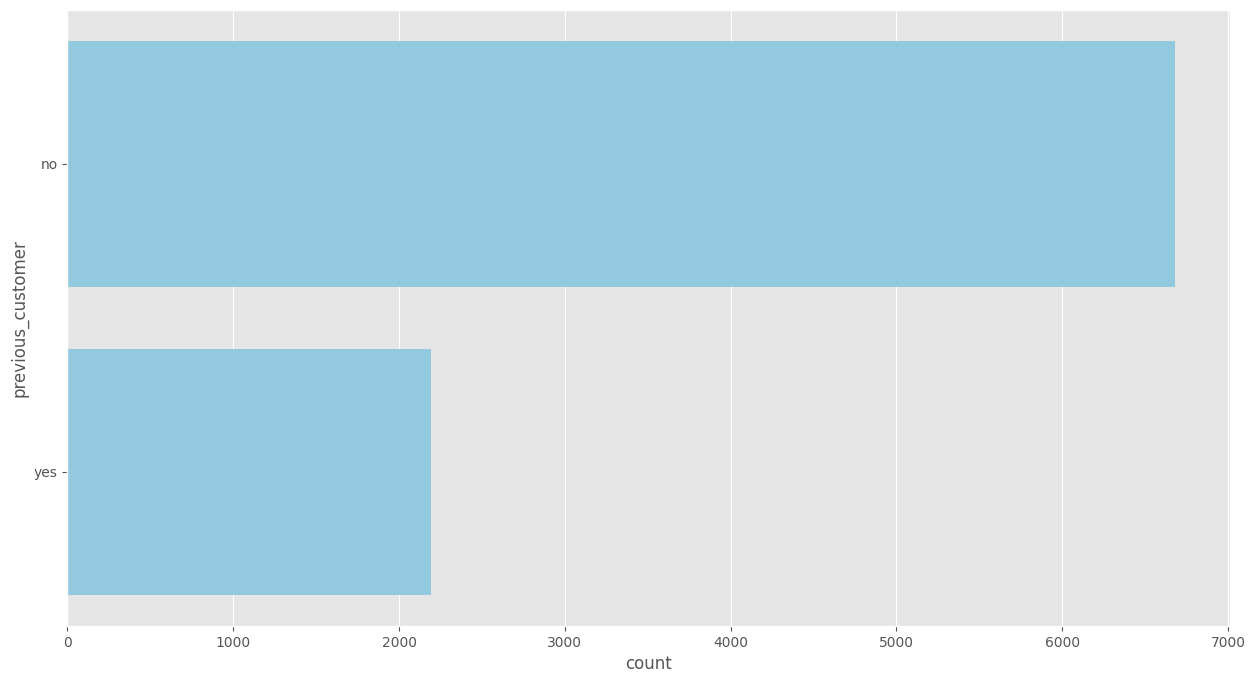

In [86]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=df, y='previous_customer', color='skyblue')
plt.show()

### heard_about_shop

In [57]:

print(df['heard_about_shop'].value_counts())

heard_about_shop
yes    5344
no     3527
Name: count, dtype: int64


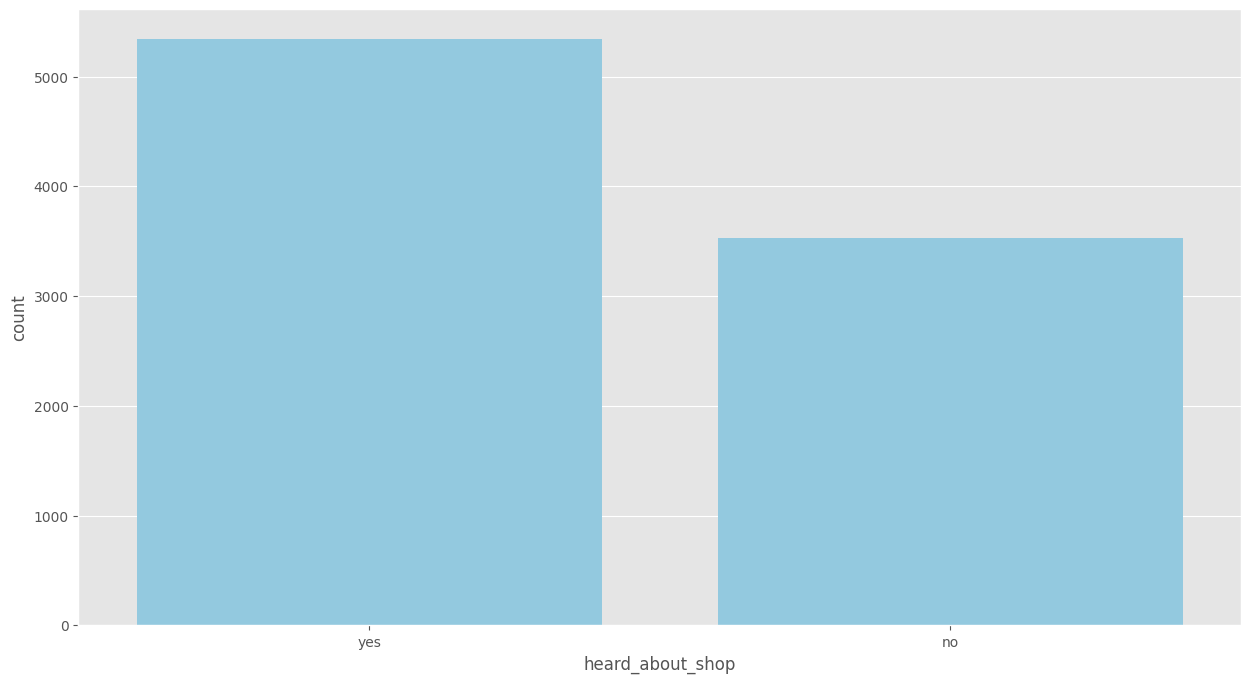

In [88]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=df, x='heard_about_shop', color='skyblue')
plt.show()

## 🔍 3.2.0 Understanding the Categroical Attributes Relationship

In [63]:
location_mobile = pd.crosstab(df['customer_location'], df['mobile_name'])



In [69]:
location_mobile.T

customer_location,inside_rangamati,outside_rangamati,rangamati_sadar
mobile_name,,,
galaxy_a55_5g_8/128,179,173,170
galaxy_m35_5g_8/128,174,189,165
galaxy_s24_ultra_12/256,176,188,177
iphone_16_pro_256gb,176,161,184
iphone_16_pro_max_1tb,156,156,176
iqoo_neo_9_pro_5g_12/256,156,190,156
iqoo_z7_5g_6/128,177,164,181
moto_g85_5g_8/128,194,180,186
narzo_n53_4/64,175,181,174


<Axes: title={'center': 'Mobile Preferences by Location'}, xlabel='mobile_name'>

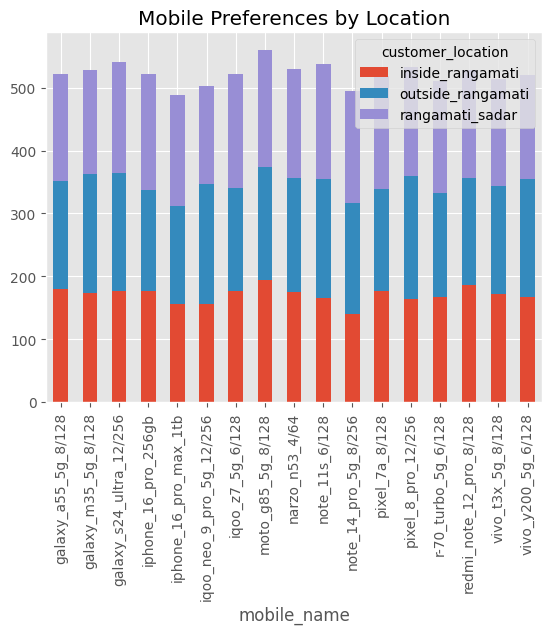

In [68]:
a.plot(kind='bar', stacked=True, title='Mobile Preferences by Location')